# Домашнее задание: Поиск аномалий в банковских транзакциях на датасете https://www.kaggle.com/mlg-ulb/creditcardfraud#creditcard.csv

## План работ
1. **Подготовка данных и окружения**:
2. **Базовый EDA**:
3. Подготовка к моделированию (формирование `X`, `y`, вопрос масштабирования `Time/Amount`).
4. Обучение нескольких unsupervised моделей из разных семейств.
5. Оценка качества (`classification_report`, `confusion_matrix` и дополнительные метрики).
6. Визуализация в сжатом пространстве (t-SNE/UMAP) и выводы.



## 1. Подготовка окружения

In [2]:
# Импортируем библиотеки для работы с данными и визуализации.


import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Настройки отображения, чтобы таблицы и графики читались удобнее.
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', None)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.width', 140)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12


### 1.1 Загрузка датасета

In [3]:
# Загружаем датасет.
# Явно указываем путь, чтобы ноутбук был воспроизводим при повторном запуске.

data_path = 'creditcard.csv'
df = pd.read_csv(data_path)

print(f'Размер данных: {df.shape[0]:,} строк x {df.shape[1]} столбцов')

df.head()

Размер данных: 284,807 строк x 31 столбцов


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Базовый EDA

На этом этапе мы проверяем качество и структуру данных до моделирования:
- корректность типов и наличие пропусков;
- дубликаты;
- базовые статистики;
- распределения признаков и целевой переменной.

Это важно, чтобы не обучать модели на «грязных» или некорректно интерпретированных данных.

### 2.1 Общая информация о данных

In [4]:
df.info()

missing = df.isna().sum().sum()
duplicates = df.duplicated().sum()

print('\nПропуски (всего):', int(missing))
print('Дубликаты (строк):', int(duplicates))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

### 2.2 Описательные статистики и баланс целевой переменной

In [5]:
from IPython.display import display

# Размер и баланс целевой переменной показываем отдельно,
# так как это ключевая информация для поиска аномалий.

# Полная описательная статистика по числовым признакам
display(df.describe().T)

# Дополнительный фокус на признаках с иной шкалой
# относительно V1..V28.
display(df[['Time', 'Amount']].describe().T)

class_counts = df['Class'].value_counts().sort_index()
class_ratio = df['Class'].mean()  # доля класса 1 (аномалий)

print('Распределение Class:')
print(class_counts)
print(f'\nДоля аномалий (Class=1): {class_ratio:.6f} ({class_ratio * 100:.4f}%)')

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,94813.859575,47488.145955,0.0,54201.5,84692.0,139320.500,172792.00
Amount,284807.0,88.349619,250.120109,0.0,5.6,22.0,77.165,25691.16


Распределение Class:
Class
0    284315
1       492
Name: count, dtype: int64

Доля аномалий (Class=1): 0.001727 (0.1727%)


### 2.4 Гистограммы признаков

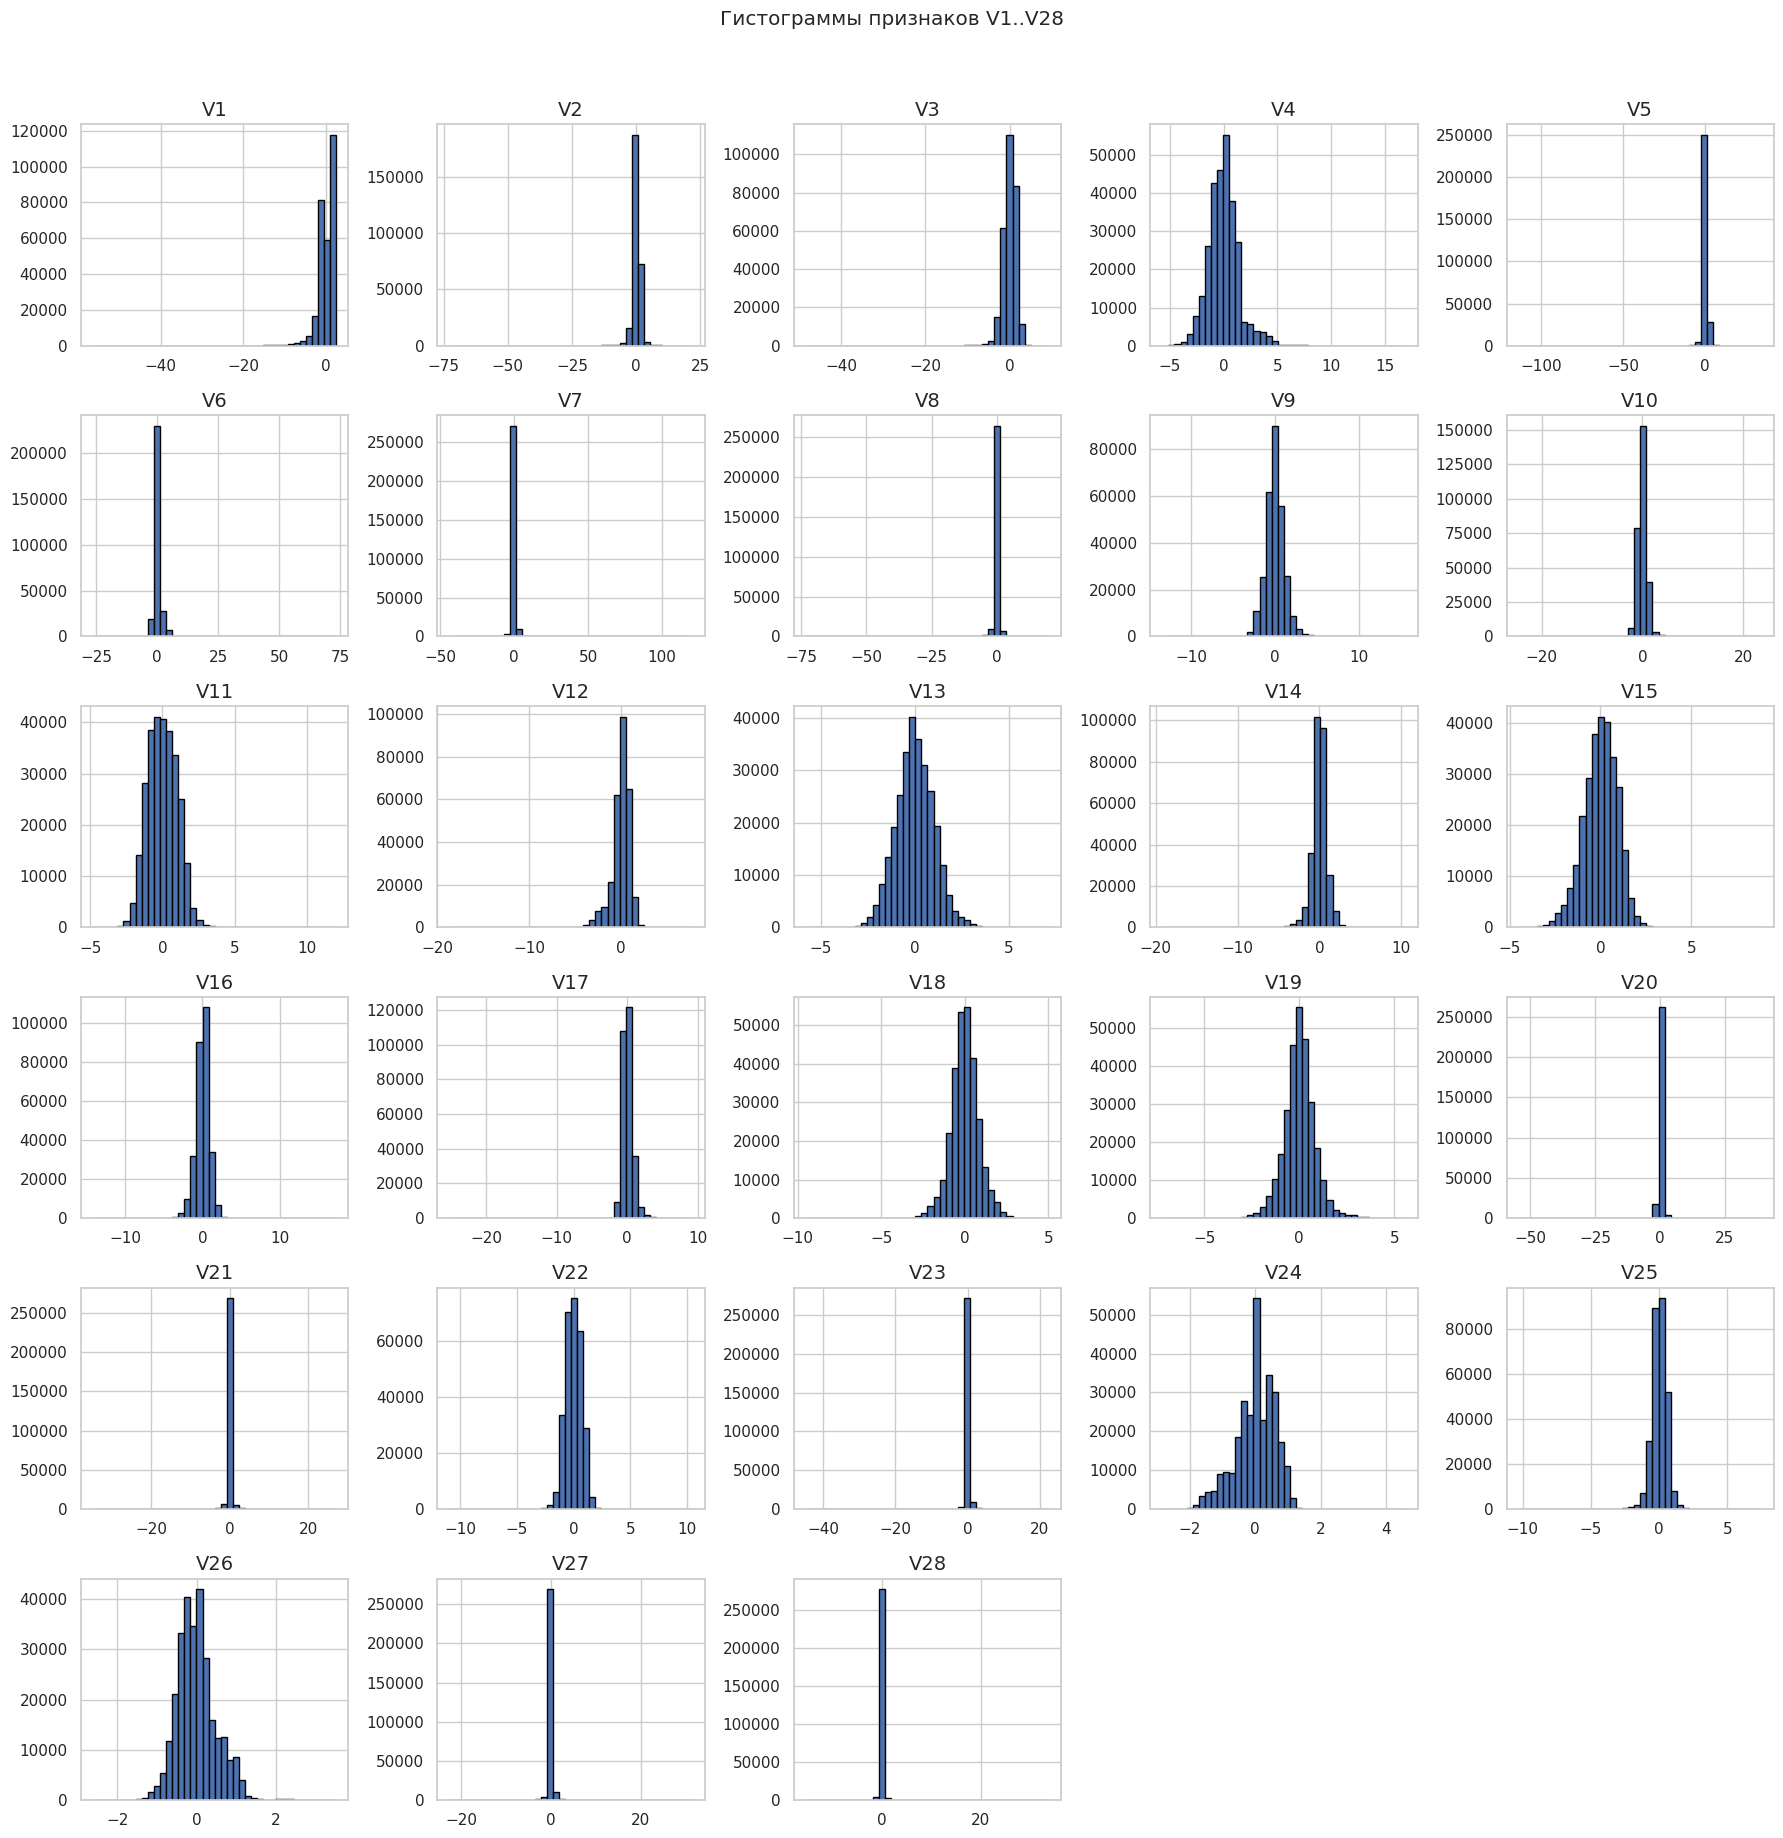

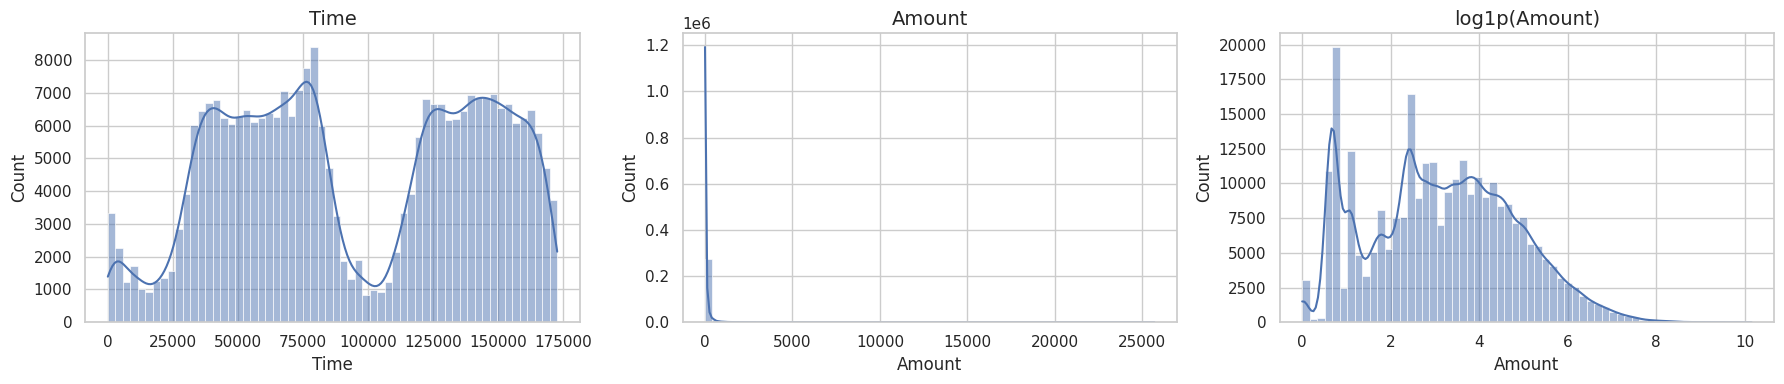

In [6]:
# Построим гистограммы.
# Сначала посмотрим признаки V1..V28, затем отдельно Time и Amount.

v_cols = [f'V{i}' for i in range(1, 29)]

df[v_cols].hist(figsize=(18, 18), bins=40, edgecolor='black')
plt.suptitle('Гистограммы признаков V1..V28', y=1.02)
plt.tight_layout()
plt.show()
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(df['Time'], bins=60, kde=True, ax=axes[0])
axes[0].set_title('Time')

sns.histplot(df['Amount'], bins=60, kde=True, ax=axes[1])
axes[1].set_title('Amount')

# log1p помогает увидеть структуру распределения Amount,
# так как исходное распределение обычно сильно скошено вправо.
sns.histplot(np.log1p(df['Amount']), bins=60, kde=True, ax=axes[2])
axes[2].set_title('log1p(Amount)')

plt.tight_layout()
plt.show()

### Выводы по пунктам 1 и 2

- Проведена базовая проверка структуры: размер, типы, пропуски, дубликаты.
- Получены описательные статистики, включая отдельный разбор `Time` и `Amount`.
- Построены гистограммы по всем `V1..V28`, а также по `Time` и `Amount`.
- Рассчитана доля аномалий `Class=1` (переменная `contamination`) — это ключевой параметр для настройки моделей на следующем этапе.


## 3. Подготовка к моделированию

На этом шаге формируем матрицу признаков `X` и целевую переменную `y` для последующей оценки качества.

Так как `Time` и `Amount` имеют существенно другой масштаб, чем остальные компоненты `V1..V28`, выполняем масштабирование `Time/Amount` с помощью `StandardScaler`.


### 3.1 Формирование признаков и целевой переменной

In [27]:
from sklearn.preprocessing import StandardScaler

# Целевая переменная (используется дальше для оценки)
y = df['Class'].values

# Признаки для unsupervised моделей
X = df.drop(columns=['Class']).copy()

# Масштабируем только Time и Amount на полном датасете
time_amount_cols = ['Time', 'Amount']
scaler = StandardScaler()

X_final = X.copy()
X_final[time_amount_cols] = scaler.fit_transform(X[time_amount_cols])

print(f'X_final shape: {X_final.shape}, y shape: {y.shape}')
print('Time: mean=', round(float(X_final["Time"].mean()), 6), 'std=', round(float(X_final["Time"].std()), 6))
print('Amount: mean=', round(float(X_final["Amount"].mean()), 6), 'std=', round(float(X_final["Amount"].std()), 6))



X_final shape: (284807, 30), y shape: (284807,)
Time: mean= -0.0 std= 1.000002
Amount: mean= 0.0 std= 1.000002


## 4. Построение разных алгоритмов

Сравним поиск аномалий методами из разных семейств.

В этом ноутбуке обучаем:

- методы из `PyOD`: `IForest`, `KNN`, `LOF`, `HBOS`, `PCA`, `CBLOF`, `ABOD`;
- отдельно `DBSCAN` из `sklearn` (аномалия = шум, `label = -1`).

Все модели обучаются по одной в отдельных ячейках, с промежуточной сводкой после каждой.
В конце формируется единая таблица по всем моделям (`summary_df`).

### 4.1 Инфраструктура обучения моделей

In [31]:
from time import perf_counter

# Алгоритмы обнаружения аномалий из PyOD
from pyod.models.knn import KNN
from pyod.models.iforest import IForest
from pyod.models.abod import ABOD
from pyod.models.cblof import CBLOF
from pyod.models.hbos import HBOS
from pyod.models.pca import PCA
from pyod.models.lof import LOF

# Кластеризация плотности из sklearn
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# Используем экспертную оценку загрязненности из шага EDA
# Если ячейка с class_ratio не запускалась, берём долю аномалий из y.
if 'class_ratio' in globals():
    contamination = float(class_ratio)
else:
    contamination = float(np.mean(y))

print(f"Целевая доля аномалий (contamination): {contamination:.6f} ({contamination * 100:.4f}%)")

results = {}
training_rows = []


def fit_detector(model_name, detector, X):
    """Обучает одну модель, сохраняет результаты и печатает промежуточную сводку."""
    start = perf_counter()
    detector.fit(X)
    elapsed = perf_counter() - start

    labels = detector.labels_.astype(int)
    scores = detector.decision_scores_

    n_anomalies = int(labels.sum())
    share_anomalies = n_anomalies / len(labels)

    results[model_name] = {
        'detector': detector,
        'labels': labels,
        'scores': scores,
        'fit_time_sec': elapsed,
        'n_anomalies': n_anomalies,
        'share_anomalies': share_anomalies,
    }

    row = {
        'model': model_name,
        'fit_time_sec': round(elapsed, 2),
        'n_anomalies': n_anomalies,
        'share_anomalies_%': round(share_anomalies * 100, 4),
    }
    training_rows.append(row)

    print(f"{model_name}: обучение завершено за {elapsed:.2f} сек")
    print(f"Обнаружено аномалий: {n_anomalies:,} ({share_anomalies * 100:.4f}%)")
    return pd.DataFrame([row])


def fit_dbscan_detector(model_name, X, min_samples=10, calibration_size=50_000):
    """Обучает DBSCAN и сохраняет результат в том же формате, что и PyOD-модели."""
    n_calib = min(calibration_size, len(X))
    calib_idx = np.random.RandomState(42).choice(len(X), size=n_calib, replace=False)
    X_calib = X.iloc[calib_idx]

    # Калибруем eps по k-distance так, чтобы доля шумовых точек была соизмерима с contamination.
    nn = NearestNeighbors(n_neighbors=min_samples, n_jobs=-1)
    nn.fit(X_calib)
    distances, _ = nn.kneighbors(X_calib)
    kth_dist = distances[:, -1]
    eps = float(np.quantile(kth_dist, 1 - contamination))

    start = perf_counter()
    detector = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
    cluster_labels = detector.fit_predict(X)
    elapsed = perf_counter() - start

    labels = (cluster_labels == -1).astype(int)
    scores = labels.astype(float)  # у DBSCAN нет непрерывного decision score

    n_anomalies = int(labels.sum())
    share_anomalies = n_anomalies / len(labels)

    results[model_name] = {
        'detector': detector,
        'labels': labels,
        'scores': scores,
        'fit_time_sec': elapsed,
        'n_anomalies': n_anomalies,
        'share_anomalies': share_anomalies,
        'eps': eps,
        'min_samples': min_samples,
    }

    row = {
        'model': model_name,
        'fit_time_sec': round(elapsed, 2),
        'n_anomalies': n_anomalies,
        'share_anomalies_%': round(share_anomalies * 100, 4),
        'eps': round(eps, 6),
        'min_samples': min_samples,
    }
    training_rows.append(row)

    print(f"{model_name}: обучение завершено за {elapsed:.2f} сек")
    print(f"Параметры DBSCAN: eps={eps:.6f}, min_samples={min_samples}")
    print(f"Обнаружено аномалий: {n_anomalies:,} ({share_anomalies * 100:.4f}%)")
    return pd.DataFrame([row])



Целевая доля аномалий (contamination): 0.001727 (0.1727%)


### 4.2 Обучение моделей по одной (запускаем ячейки отдельно)

Каждая ячейка ниже обучает ровно одну модель и сразу выводит промежуточный результат.

In [32]:
# 1) IForest
fit_detector(
    model_name='IForest',
    detector=IForest(contamination=contamination),
    X=X_final
)



IForest: обучение завершено за 2.30 сек
Обнаружено аномалий: 492 (0.1727%)


,model,fit_time_sec,n_anomalies,share_anomalies_%
0,IForest,2.3,492,0.1727


In [33]:
# 2) KNN
fit_detector(
    model_name='KNN',
    detector=KNN(contamination=contamination),
    X=X_final
)



KNN: обучение завершено за 111.56 сек
Обнаружено аномалий: 492 (0.1727%)


,model,fit_time_sec,n_anomalies,share_anomalies_%
0,KNN,111.56,492,0.1727


In [ ]:
# 3) DBSCAN
fit_dbscan_detector(
    model_name='DBSCAN',
    X=X_final,
    min_samples=10,
    calibration_size=50_000
)



In [34]:
# 4) ABOD benchmark (оценка времени до полного запуска)
# Идея: измеряем время на подвыборке и экстраполируем ~ O(N^2).
N_BENCH = min(20_000, len(X_final))
RANDOM_STATE = 42

rng = np.random.RandomState(RANDOM_STATE)
bench_idx = rng.choice(len(X_final), size=N_BENCH, replace=False)
X_bench = X_final.iloc[bench_idx]

abod_bench = ABOD(contamination=contamination, n_neighbors=10)

start_bench = perf_counter()
abod_bench.fit(X_bench)
bench_time_sec = perf_counter() - start_bench

scale = (len(X_final) / N_BENCH) ** 2
est_full_sec = bench_time_sec * scale

print(f"ABOD benchmark: {N_BENCH:,} объектов")
print(f"Фактическое время на подвыборке: {bench_time_sec:.2f} сек")
print(f"Оценка времени на полном датасете (~O(N^2)): {est_full_sec / 60:.1f} мин ({est_full_sec / 3600:.2f} ч)")



ABOD benchmark: 20,000 объектов
Фактическое время на подвыборке: 6.61 сек
Оценка времени на полном датасете (~O(N^2)): 22.3 мин (0.37 ч)


In [ ]:
# 5) ABOD
# Важно: на полном датасете может обучаться очень долго.
fit_detector(
    model_name='ABOD',
    detector=ABOD(contamination=contamination, n_neighbors=10),
    X=X_final
)



In [35]:
# 6) LOF
fit_detector(
    model_name='LOF',
    detector=LOF(contamination=contamination, n_neighbors=20),
    X=X_final
)



LOF: обучение завершено за 86.24 сек
Обнаружено аномалий: 492 (0.1727%)


,model,fit_time_sec,n_anomalies,share_anomalies_%
0,LOF,86.24,492,0.1727


In [36]:
# 7) HBOS
fit_detector(
    model_name='HBOS',
    detector=HBOS(contamination=contamination),
    X=X_final
)



HBOS: обучение завершено за 0.33 сек
Обнаружено аномалий: 492 (0.1727%)


,model,fit_time_sec,n_anomalies,share_anomalies_%
0,HBOS,0.33,492,0.1727


In [37]:
# 8) PCA detector
fit_detector(
    model_name='PCA',
    detector=PCA(contamination=contamination),
    X=X_final
)



PCA: обучение завершено за 0.26 сек
Обнаружено аномалий: 492 (0.1727%)


,model,fit_time_sec,n_anomalies,share_anomalies_%
0,PCA,0.26,492,0.1727


In [38]:
# 9) CBLOF
fit_detector(
    model_name='CBLOF',
    detector=CBLOF(contamination=contamination),
    X=X_final
)



CBLOF: обучение завершено за 0.59 сек
Обнаружено аномалий: 492 (0.1727%)


,model,fit_time_sec,n_anomalies,share_anomalies_%
0,CBLOF,0.59,492,0.1727


### 4.3 Сводный результат по всем обученным моделям

In [39]:
from IPython.display import display

if training_rows:
    summary_df = pd.DataFrame(training_rows).sort_values('fit_time_sec', ascending=False).reset_index(drop=True)
    display(summary_df)
else:
    print('Пока нет результатов. Запустите ячейки с обучением моделей выше.')

,model,fit_time_sec,n_anomalies,share_anomalies_%
0,KNN,111.56,492,0.1727
1,LOF,86.24,492,0.1727
2,IForest,2.30,492,0.1727
3,CBLOF,0.59,492,0.1727
4,HBOS,0.33,492,0.1727
5,PCA,0.26,492,0.1727


### 4.4 Диагностика: насколько совпадают метки аномалий

In [40]:
if results:
    model_names = list(results.keys())
    labels_df = pd.DataFrame({name: results[name]['labels'] for name in model_names})

    # Количество уникальных комбинаций меток по объектам
    unique_patterns = labels_df.drop_duplicates().shape[0]
    print(f"Уникальных паттернов предсказаний по объектам: {unique_patterns}")

    # Доля точного совпадения меток между парами моделей
    agreement = pd.DataFrame(index=model_names, columns=model_names, dtype=float)
    for m1 in model_names:
        for m2 in model_names:
            agreement.loc[m1, m2] = (labels_df[m1].values == labels_df[m2].values).mean()

    print('\nМатрица точного совпадения меток (доля от 0 до 1):')
    display(agreement.round(4))

    # Если нужны сами пары с максимальными расхождениями
    pairs = []
    for i, m1 in enumerate(model_names):
        for m2 in model_names[i+1:]:
            eq = float((labels_df[m1].values == labels_df[m2].values).mean())
            pairs.append((m1, m2, eq))
    pairs_df = pd.DataFrame(pairs, columns=['model_1', 'model_2', 'agreement']).sort_values('agreement')

    print('\nПары моделей с наименьшим совпадением:')
    display(pairs_df.head(10).round({'agreement': 4}))
else:
    print('Словарь results пуст. Сначала запустите ячейки обучения моделей.')

Уникальных паттернов предсказаний по объектам: 33

Матрица точного совпадения меток (доля от 0 до 1):


,IForest,KNN,LOF,HBOS,PCA,CBLOF
IForest,1.0000,0.9983,0.9966,0.9991,0.9991,0.9988
KNN,0.9983,1.0000,0.9966,0.9979,0.9984,0.9981
LOF,0.9966,0.9966,1.0000,0.9966,0.9966,0.9966
HBOS,0.9991,0.9979,0.9966,1.0000,0.9990,0.9989
PCA,0.9991,0.9984,0.9966,0.9990,1.0000,0.9995
CBLOF,0.9988,0.9981,0.9966,0.9989,0.9995,1.0000



Пары моделей с наименьшим совпадением:


,model_1,model_2,agreement
10,LOF,PCA,0.9966
11,LOF,CBLOF,0.9966
5,KNN,LOF,0.9966
9,LOF,HBOS,0.9966
1,IForest,LOF,0.9966
6,KNN,HBOS,0.9979
8,KNN,CBLOF,0.9981
0,IForest,KNN,0.9983
7,KNN,PCA,0.9984
4,IForest,CBLOF,0.9988


## 5. Оценка качества моделей (classification report + confusion matrix)

В этом блоке сравниваем предсказания моделей с истинной переменной `Class`.
Для каждой модели выводим:

- `classification_report`;
- `confusion_matrix`;
- ключевые метрики по классу аномалий (`Class=1`) в общей сводной таблице.

### 5.1 Импорты и проверка готовности

In [41]:
from sklearn.metrics import classification_report, confusion_matrix

if not results:
    print('Словарь results пуст. Сначала обучите модели в разделе 4.')
else:
    print(f'Готово к оценке: моделей в results = {len(results)}')

Готово к оценке: моделей в results = 6


### 5.2 Отчеты по каждой модели

In [42]:
if not results:
    print('Сначала запустите обучение моделей (раздел 4).')
else:
    metric_rows = []

    for model_name, payload in results.items():
        y_pred = np.asarray(payload['labels']).astype(int)

        print('=' * 90)
        print(f'Модель: {model_name}')

        # Classification report (как требует задание)
        report_dict = classification_report(y, y_pred, output_dict=True, zero_division=0)
        print('\nClassification report:')
        print(classification_report(y, y_pred, zero_division=0))

        # Confusion matrix (как требует задание)
        cm = confusion_matrix(y, y_pred, labels=[0, 1])
        cm_df = pd.DataFrame(
            cm,
            index=['True 0 (normal)', 'True 1 (fraud)'],
            columns=['Pred 0 (normal)', 'Pred 1 (fraud)']
        )
        print('Confusion matrix:')
        display(cm_df)

        # Сохраняем ключевые метрики для общей сводки
        metric_rows.append({
            'model': model_name,
            'precision_class_1': report_dict['1']['precision'],
            'recall_class_1': report_dict['1']['recall'],
            'f1_class_1': report_dict['1']['f1-score'],
            'support_class_1': int(report_dict['1']['support']),
            'accuracy': report_dict['accuracy'],
        })

    metrics_summary_df = pd.DataFrame(metric_rows).sort_values('f1_class_1', ascending=False).reset_index(drop=True)



Модель: IForest

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.22      0.22      0.22       492

    accuracy                           1.00    284807
   macro avg       0.61      0.61      0.61    284807
weighted avg       1.00      1.00      1.00    284807

Confusion matrix:


,Pred 0 (normal),Pred 1 (fraud)
True 0 (normal),283932,383
True 1 (fraud),383,109


Модель: KNN

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.10      0.10      0.10       492

    accuracy                           1.00    284807
   macro avg       0.55      0.55      0.55    284807
weighted avg       1.00      1.00      1.00    284807

Confusion matrix:


,Pred 0 (normal),Pred 1 (fraud)
True 0 (normal),283872,443
True 1 (fraud),443,49


Модель: LOF

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.00      0.00      0.00       492

    accuracy                           1.00    284807
   macro avg       0.50      0.50      0.50    284807
weighted avg       1.00      1.00      1.00    284807

Confusion matrix:


...

,Pred 0 (normal),Pred 1 (fraud)
True 0 (normal),283997,318
True 1 (fraud),318,174


Модель: PCA

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.23      0.23      0.23       492

    accuracy                           1.00    284807
   macro avg       0.62      0.62      0.62    284807
weighted avg       1.00      1.00      1.00    284807

Confusion matrix:


,Pred 0 (normal),Pred 1 (fraud)
True 0 (normal),283937,378
True 1 (fraud),378,114


Модель: CBLOF

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.27      0.27      0.27       492

    accuracy                           1.00    284807
   macro avg       0.63      0.63      0.63    284807
weighted avg       1.00      1.00      1.00    284807

Confusion matrix:


,Pred 0 (normal),Pred 1 (fraud)
True 0 (normal),283956,359
True 1 (fraud),359,133


### 5.3 Сводная таблица метрик качества

In [43]:
if 'metrics_summary_df' in globals():
    metrics_summary_df[['precision_class_1', 'recall_class_1', 'f1_class_1', 'accuracy']] = (
        metrics_summary_df[['precision_class_1', 'recall_class_1', 'f1_class_1', 'accuracy']].round(4)
    )
    display(metrics_summary_df)
else:
    print('Сводка метрик еще не сформирована. Запустите ячейку 5.2.')

,model,precision_class_1,recall_class_1,f1_class_1,support_class_1,accuracy
0,HBOS,0.3537,0.3537,0.3537,492,0.9978
1,CBLOF,0.2703,0.2703,0.2703,492,0.9975
2,PCA,0.2317,0.2317,0.2317,492,0.9973
3,IForest,0.2215,0.2215,0.2215,492,0.9973
4,KNN,0.0996,0.0996,0.0996,492,0.9969
5,LOF,0.0000,0.0000,0.0000,492,0.9965


### Выводы по пункту 5

По результатам оценки качества на переменной `Class` **лучшей моделью** в данном эксперименте оказался `HBOS` (`precision = recall = f1 = 0.3537` для класса аномалий), что соответствует примерно 174 корректно найденным мошенническим транзакциям из 492.

**Второй результат** показал `IForest` (`f1 = 0.2337`), близкие значения также у `PCA` и `CBLOF`.

Модели `KNN` и особенно `LOF` в текущих настройках показали слабое качество.

При этом высокая `accuracy` у всех моделей обусловлена сильным дисбалансом классов и сама по себе не является информативной.

Для данной задачи ключевыми являются метрики по классу `1` (аномалии), прежде всего `recall`, `precision` и `f1-score`.

## 6. Сжатое представление данных (UMAP / t-SNE)

В этом блоке строим 2D-проекцию признакового пространства и проверяем,
насколько аномалии отделены от основной массы точек.

Практический подход:
- используем стратифицированную подвыборку (чтобы ускорить вычисления и сохранить редкий класс);
- сначала пробуем `UMAP` (обычно быстрее и лучше сохраняет структуру),
  при отсутствии библиотеки автоматически переходим к `t-SNE`;
- сравниваем распределение истинных меток `Class` и предсказаний лучших моделей.

### 6.1 Подготовка подвыборки для визуализации

In [44]:
from sklearn.model_selection import train_test_split

# Размер подвыборки: можно увеличить при необходимости.
# 30_000 обычно дает хороший компромисс между скоростью и качеством картинки.
VIS_SAMPLE_SIZE = 30_000
RANDOM_STATE = 42

X_vis_base = X_final
y_vis_base = np.asarray(y).astype(int)

all_idx = np.arange(len(X_vis_base))
if VIS_SAMPLE_SIZE >= len(X_vis_base):
    vis_idx = all_idx
else:
    vis_idx, _ = train_test_split(
        all_idx,
        train_size=VIS_SAMPLE_SIZE,
        stratify=y_vis_base,
        random_state=RANDOM_STATE,
    )

X_vis = X_vis_base.iloc[vis_idx].reset_index(drop=True)
y_vis = y_vis_base[vis_idx].astype(int)

print(f'Размер подвыборки для проекции: {len(X_vis):,}')
print(f'Доля аномалий в подвыборке: {y_vis.mean():.6f} ({y_vis.mean() * 100:.4f}%)')



Размер подвыборки для проекции: 30,000
Доля аномалий в подвыборке: 0.001733 (0.1733%)


### 6.2 Построение 2D-проекции (UMAP -> fallback t-SNE)

In [45]:
from time import perf_counter
from sklearn.manifold import TSNE

start = perf_counter()

try:
    import umap

    reducer_name = 'UMAP'
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=30,
        min_dist=0.1,
        metric='euclidean',
        random_state=RANDOM_STATE,
    )
    embedding = reducer.fit_transform(X_vis)
except Exception as e:
    reducer_name = 't-SNE'
    print(f'UMAP недоступен ({e}). Переключаемся на t-SNE...')
    reducer = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate='auto',
        init='pca',
        random_state=RANDOM_STATE,
    )
    embedding = reducer.fit_transform(X_vis)

elapsed = perf_counter() - start
embedding_df = pd.DataFrame(embedding, columns=['dim1', 'dim2'])

print(f'Использован метод: {reducer_name}')
print(f'Время построения проекции: {elapsed:.2f} сек')

UMAP недоступен (No module named 'umap'). Переключаемся на t-SNE...
Использован метод: t-SNE
Время построения проекции: 77.65 сек


### 6.3 Визуализация и проверка отделимости аномалий

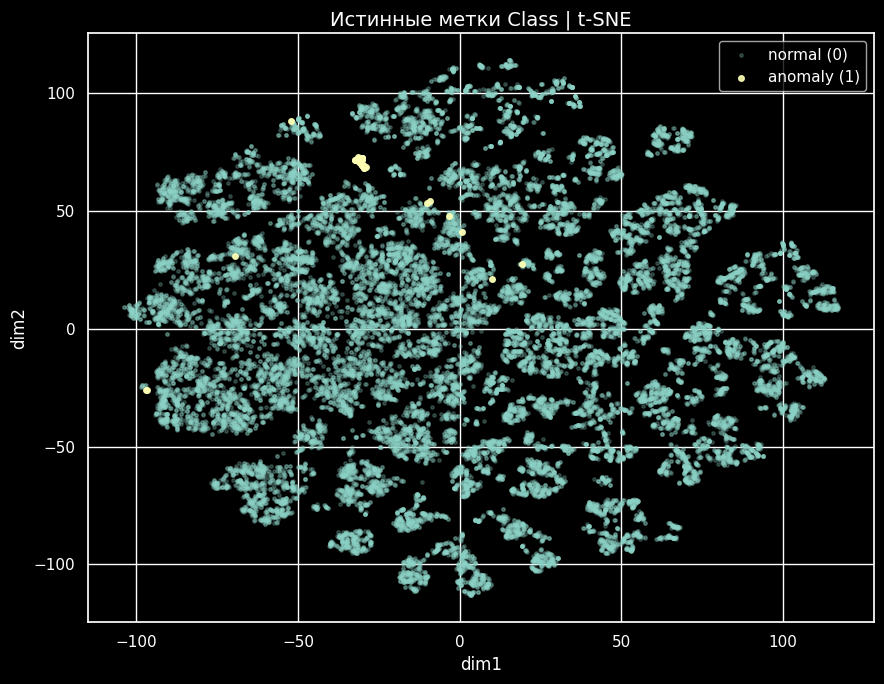

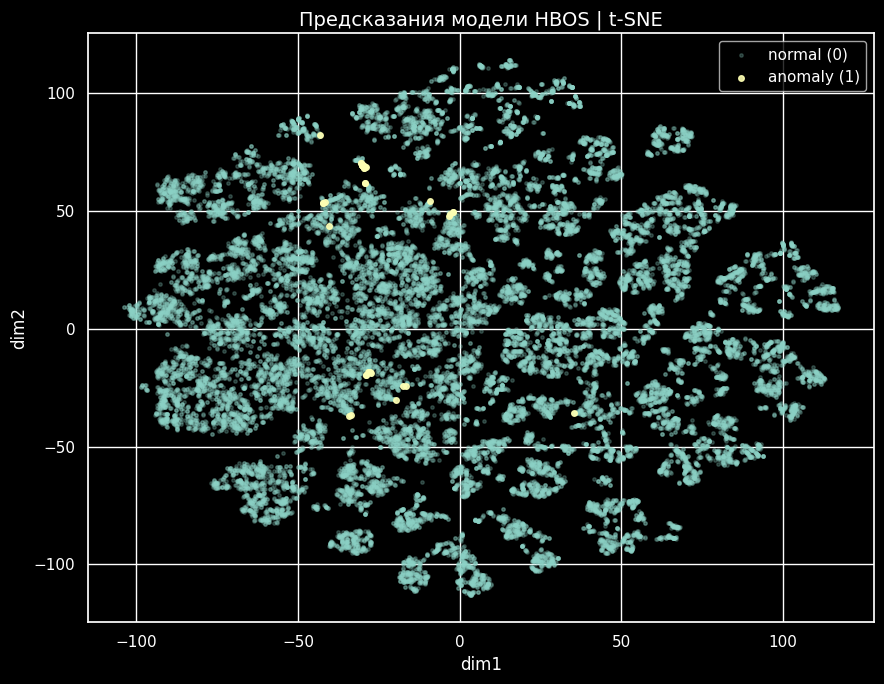

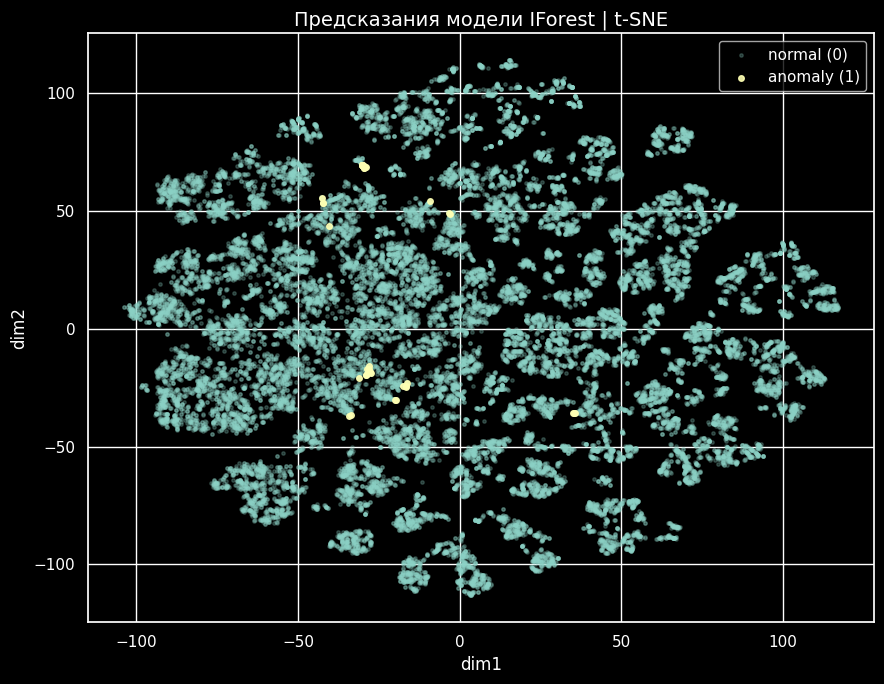

,source,normal_n,anomaly_n,median_dist_normal,median_dist_anomaly,distance_ratio
0,Class (ground truth),29948,52,70.4224,77.9226,1.1065
1,HBOS,29958,42,70.4816,68.6326,0.9738
2,IForest,29956,44,70.4909,49.9618,0.7088


Интерпретация: чем больше distance_ratio (>1), тем дальше аномалии от центра основной массы.


In [46]:
def plot_embedding(labels, title):
    labels = np.asarray(labels).astype(int)
    plt.figure(figsize=(9, 7))

    normal_mask = labels == 0
    anomaly_mask = labels == 1

    plt.scatter(
        embedding_df.loc[normal_mask, 'dim1'],
        embedding_df.loc[normal_mask, 'dim2'],
        s=6,
        alpha=0.25,
        label='normal (0)'
    )
    plt.scatter(
        embedding_df.loc[anomaly_mask, 'dim1'],
        embedding_df.loc[anomaly_mask, 'dim2'],
        s=16,
        alpha=0.9,
        label='anomaly (1)'
    )

    plt.title(f'{title} | {reducer_name}')
    plt.xlabel('dim1')
    plt.ylabel('dim2')
    plt.legend()
    plt.tight_layout()
    plt.show()


def separation_summary(labels, name):
    """Простая численная проверка: аномалии дальше от центра нормальных точек."""
    labels = np.asarray(labels).astype(int)
    normal = embedding_df.loc[labels == 0, ['dim1', 'dim2']].values
    anomaly = embedding_df.loc[labels == 1, ['dim1', 'dim2']].values

    if len(normal) == 0 or len(anomaly) == 0:
        return {'source': name, 'normal_n': len(normal), 'anomaly_n': len(anomaly), 'distance_ratio': np.nan}

    normal_center = normal.mean(axis=0)
    d_normal = np.linalg.norm(normal - normal_center, axis=1)
    d_anomaly = np.linalg.norm(anomaly - normal_center, axis=1)

    ratio = float(np.median(d_anomaly) / (np.median(d_normal) + 1e-12))
    return {
        'source': name,
        'normal_n': int(len(normal)),
        'anomaly_n': int(len(anomaly)),
        'median_dist_normal': float(np.median(d_normal)),
        'median_dist_anomaly': float(np.median(d_anomaly)),
        'distance_ratio': ratio,
    }


# 1) Истинная разметка
plot_embedding(y_vis, 'Истинные метки Class')
separation_rows = [separation_summary(y_vis, 'Class (ground truth)')]

# 2) Предсказания лучших моделей (если они были обучены)
candidate_models = ['HBOS', 'IForest']
for model_name in candidate_models:
    if model_name in results:
        model_labels_full = np.asarray(results[model_name]['labels']).astype(int)

        if len(model_labels_full) == len(y_vis):
            model_labels_vis = model_labels_full
        elif len(model_labels_full) > np.max(vis_idx):
            model_labels_vis = model_labels_full[vis_idx]
        else:
            print(f'Пропуск {model_name}: несовместимая длина labels ({len(model_labels_full)}) и vis_idx.')
            continue

        plot_embedding(model_labels_vis, f'Предсказания модели {model_name}')
        separation_rows.append(separation_summary(model_labels_vis, model_name))

# Сводная численная оценка
separation_df = pd.DataFrame(separation_rows)
if not separation_df.empty:
    num_cols = ['median_dist_normal', 'median_dist_anomaly', 'distance_ratio']
    for c in num_cols:
        if c in separation_df.columns:
            separation_df[c] = separation_df[c].round(4)
    display(separation_df)
    print('Интерпретация: чем больше distance_ratio (>1), тем дальше аномалии от центра основной массы.')



> Ниже оставлена пустая кодовая ячейка для дополнительных экспериментов.